In [13]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
# np.random.seed(42) - ensures same randomness every run - reproducibility and consistency

In [15]:
def compute_log_returns(prices):
    return np.log(prices / prices.shift(1)).dropna()

def standardize_returns(returns):
    scaler = StandardScaler()
    standardized = scaler.fit_transform(returns)
    return pd.DataFrame(standardized, columns=returns.columns, index=returns.index)

def perform_pca(data, n_components=None):
    pca = PCA(n_components=n_components)
    pca.fit(data)
    return pca, pca.explained_variance_, pca.components_, pca.explained_variance_ratio_

def compute_scores(data, eigenvectors):
    return data @ eigenvectors.T

# PART 1 - Understanding Returns and Covariance Structure

In [16]:
n_stocks = 10
n_days = 500
initial_price = 100
# same start because we want to emerge differences due to drift, beta and volatility.

In [17]:
mu = np.random.uniform(0.0001, 0.0005, n_stocks)
beta = np.random.uniform(0.5, 1.5, n_stocks)
sigma = np.random.uniform(0.005, 0.02, n_stocks)

In [18]:
market_factor = np.random.normal(0, 0.01, n_days)
# ft - represents the overall market movement, this is used by all stocks in their price eqn.

# (a)
Generate 500 days of prices for 10 stocks using the process above. Choose reasonable
parameters: Pi,0 = 100, μi ~ U(0.0001, 0.0005), βi ~ U(0.5, 1.5), σi ~ U(0.005, 0.02). Plot all 10
price series on a single chart.

In [19]:
prices = np.zeros((n_days, n_stocks))
prices[0] = initial_price
# 500 days x 10 stocks matrix

In [20]:
# stock price generation code
for t in range(1, n_days):
    epsilon = np.random.normal(0, sigma)
    # individual random shock for each stock
    prices[t] = ( prices[t-1] * np.exp(mu + beta * market_factor[t] + epsilon))

In [21]:
# creating dataframe - for easier plotting and heatmaps further
stock_names = [f"Stock_{i+1}" for i in range(n_stocks)]
prices_df = pd.DataFrame(prices, columns=stock_names)
prices_df.head()
# shows first 5 rows here, for more rows can change to prices_df.head(x) where x is number of rows visbile. 


,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,97.934694,100.636391,100.786630,99.354544,101.033869,97.516709,100.261987,98.896156,99.480375,100.363246
2,96.469326,99.527894,100.971323,98.366555,101.638091,95.309313,100.214723,100.152013,95.619944,99.473089
3,97.138520,99.006996,100.970142,97.575202,101.556699,94.886798,100.930177,100.221333,95.841086,99.049136
4,96.191620,97.881580,100.574733,96.762377,101.505026,97.861696,101.157403,99.237563,96.941204,98.387493


In [22]:
prices_df.to_csv("../data/synthetic_prices.csv", index=False)

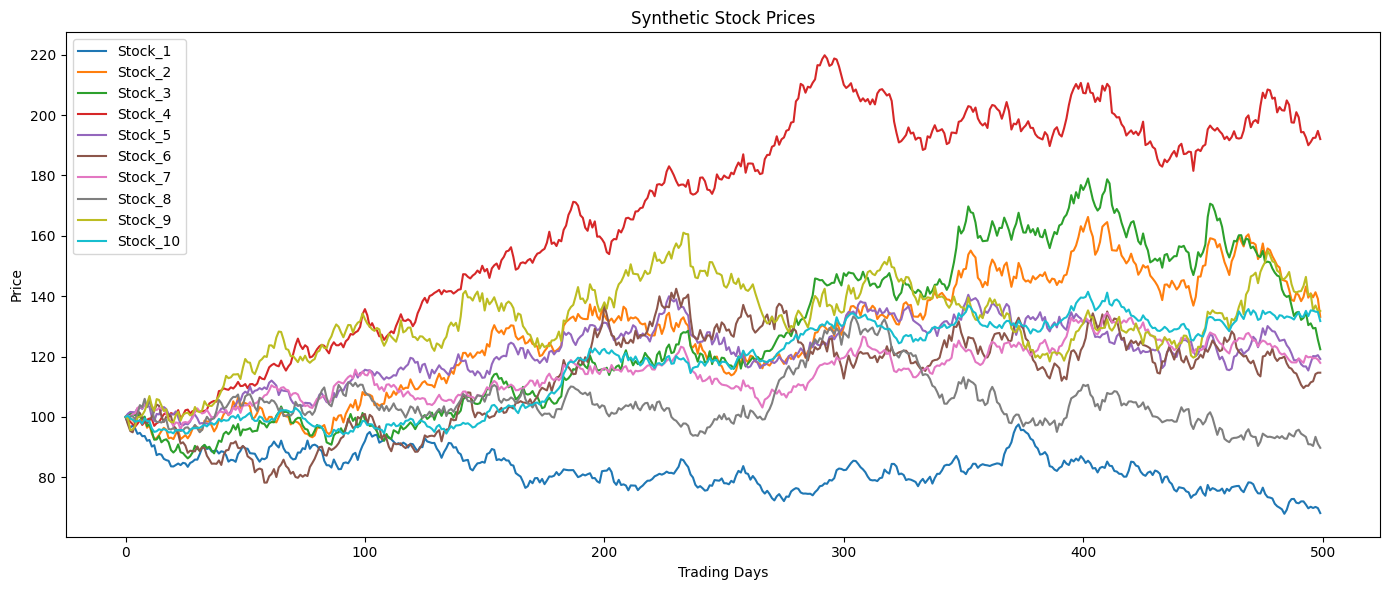

In [23]:
#plots 
plt.figure(figsize=(14,6))
for col in prices_df.columns:
    plt.plot(prices_df[col], label=col)
plt.title("Synthetic Stock Prices")
plt.xlabel("Trading Days")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.savefig("../plots/price_series.png")
plt.show()

# (b)
Compute daily log returns: ri,t = ln(Pi,t / Pi,t−1). Explain in a markdown cell why PCA must be
performed on returns (or a stationary transformation) rather than on prices directly.

In [24]:
# log returns
log_returns = np.log(prices_df / prices_df.shift(1))
log_returns = log_returns.dropna()
# dropna so that first row becomes NaN as day0 has no previous day.
display(log_returns.head())
# gives 499x10 matrix

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
1,-0.020869,0.006344,0.007836,-0.006475,0.010286,-0.025146,0.002616,-0.011100,-0.005210,0.003626
2,-0.015076,-0.011076,0.001831,-0.009994,0.005963,-0.022896,-0.000472,0.012619,-0.039579,-0.008909
3,0.006913,-0.005247,-0.000012,-0.008077,-0.000801,-0.004443,0.007114,0.000692,0.002310,-0.004271
4,-0.009796,-0.011432,-0.003924,-0.008365,-0.000509,0.030871,0.002249,-0.009864,0.011413,-0.006702
5,-0.019004,0.020557,0.007521,0.009845,0.013010,0.040948,0.017634,0.016642,0.029120,0.002443


In [25]:

log_returns.to_csv("../data/log_returns.csv", index=False)

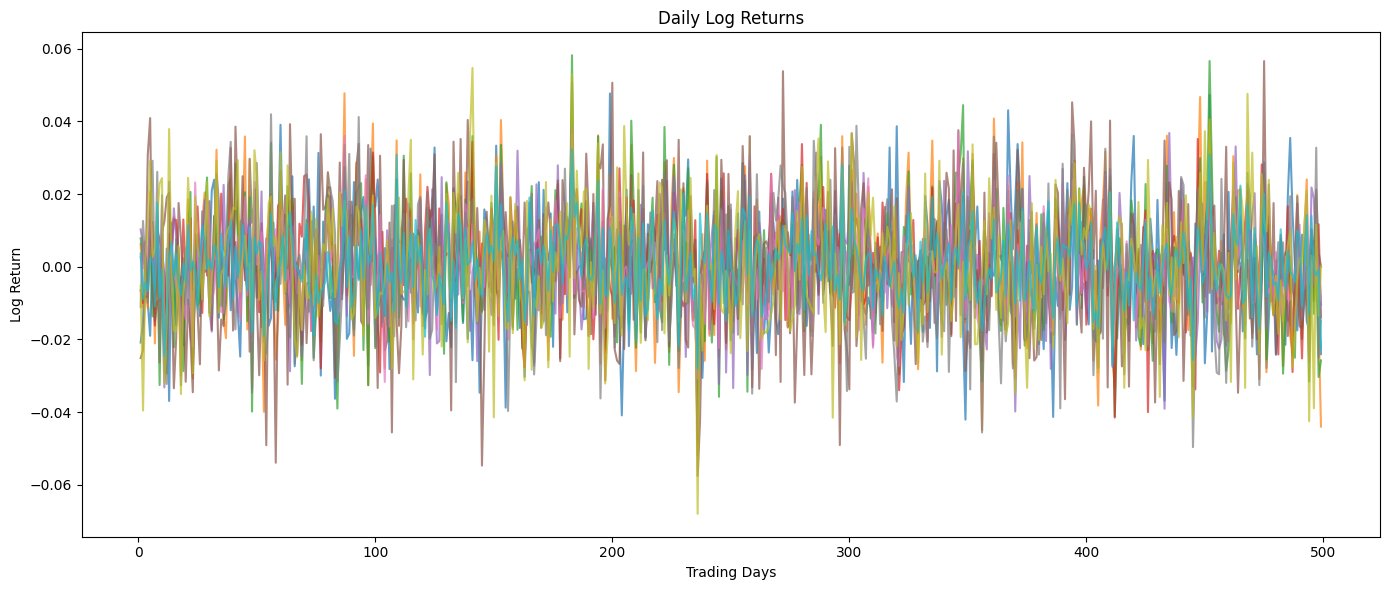

In [26]:
# log returns plot - to support reasoning to part (b)
plt.figure(figsize=(14,6))
for col in log_returns.columns:
    plt.plot(log_returns[col], alpha=0.7)
plt.title("Daily Log Returns")
plt.xlabel("Trading Days")
plt.ylabel("Log Return")
plt.tight_layout()
plt.savefig("../plots/log_returns.png")
plt.show()

# Explain in a markdown cell why PCA must be performed on returns (or a stationary transformation) rather than on prices directly

# Solution -

PCA should be applied to returns rather than stock prices because stock prices are generally
- non-stationary
- consist long term trends
- they evolve over time and are heavily influenced by scale, which makes direct comparision between the assets unreliable.
For example,
- A stock priced around 500 may contribute much larger numerical variations than a stock priced around 50, even if both move similarly in percentage terms.

Daily log returns remove much of this trend and scale dependence by measuring relative percentage movement between consecutive trading days. Using returns provide several advantages such as -
- returns are more stationary than prices.
- It is easier to analyze volatility in case of returns.
- Assets become comparable irrespective of price scale.
- Covariance and correlation structures become more meaningful.
- PCA is able to identify latent common market factors instead of simple price-level differences.

The visualization of log returns plotted above further confirms this behavior. Unlike prices, which exhibit long-term trending patterns, returns fluctuate around zero and display relatively stable variance over time. This makes returns statistically more suitable for covariance analysis and dimensionality reduction using PCA.

Therefore, returns provide a cleaner representation of the true dependency structure between assets and form the appropriate input for PCA.

# (c)

Compute the 10×10 correlation matrix and the 10×10
covariance matrix of the returns. Visualize
both as heatmaps. Identify which pair of stocks has the highest and lowest correlation

In [27]:
#correlation and covariance matrices
correlation_matrix = log_returns.corr()
covariance_matrix = log_returns.cov()
display(correlation_matrix)
display(covariance_matrix)

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
Stock_1,1.000000,0.320880,0.304488,0.148427,0.193885,0.155942,0.274627,0.180794,0.199914,0.313248
Stock_2,0.320880,1.000000,0.758583,0.513821,0.498209,0.275130,0.650398,0.548901,0.501024,0.704862
Stock_3,0.304488,0.758583,1.000000,0.510424,0.395707,0.268143,0.604958,0.516400,0.437364,0.637563
Stock_4,0.148427,0.513821,0.510424,1.000000,0.288422,0.197022,0.422605,0.407971,0.338690,0.450649
Stock_5,0.193885,0.498209,0.395707,0.288422,1.000000,0.214227,0.422022,0.318336,0.298716,0.404811
Stock_6,0.155942,0.275130,0.268143,0.197022,0.214227,1.000000,0.222752,0.170375,0.237671,0.250297
Stock_7,0.274627,0.650398,0.604958,0.422605,0.422022,0.222752,1.000000,0.442211,0.405379,0.543591
Stock_8,0.180794,0.548901,0.516400,0.407971,0.318336,0.170375,0.442211,1.000000,0.288745,0.506067
Stock_9,0.199914,0.501024,0.437364,0.338690,0.298716,0.237671,0.405379,0.288745,1.000000,0.424168
Stock_10,0.313248,0.704862,0.637563,0.450649,0.404811,0.250297,0.543591,0.506067,0.424168,1.000000


,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
Stock_1,0.000233,0.000081,0.000075,0.000028,0.000040,0.000045,0.000047,0.000044,0.000052,0.000046
Stock_2,0.000081,0.000272,0.000202,0.000104,0.000110,0.000086,0.000120,0.000143,0.000140,0.000112
Stock_3,0.000075,0.000202,0.000261,0.000101,0.000086,0.000082,0.000109,0.000132,0.000119,0.000099
Stock_4,0.000028,0.000104,0.000101,0.000150,0.000047,0.000045,0.000058,0.000079,0.000070,0.000053
Stock_5,0.000040,0.000110,0.000086,0.000047,0.000180,0.000054,0.000063,0.000067,0.000068,0.000052
Stock_6,0.000045,0.000086,0.000082,0.000045,0.000054,0.000355,0.000047,0.000051,0.000076,0.000045
Stock_7,0.000047,0.000120,0.000109,0.000058,0.000063,0.000047,0.000125,0.000078,0.000077,0.000058
Stock_8,0.000044,0.000143,0.000132,0.000079,0.000067,0.000051,0.000078,0.000249,0.000077,0.000077
Stock_9,0.000052,0.000140,0.000119,0.000070,0.000068,0.000076,0.000077,0.000077,0.000286,0.000069
Stock_10,0.000046,0.000112,0.000099,0.000053,0.000052,0.000045,0.000058,0.000077,0.000069,0.000093


In [28]:

correlation_matrix.to_csv("../data/correlation_matrix.csv")
covariance_matrix.to_csv("../data/covariance_matrix.csv")

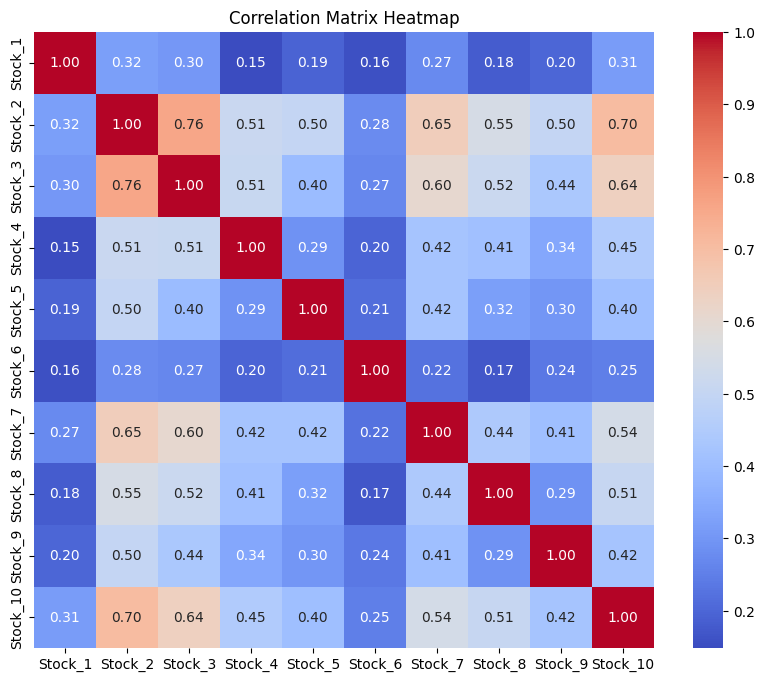

In [29]:
#correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix Heatmap")
plt.savefig("../plots/correlation_heatmap.png")
plt.show()

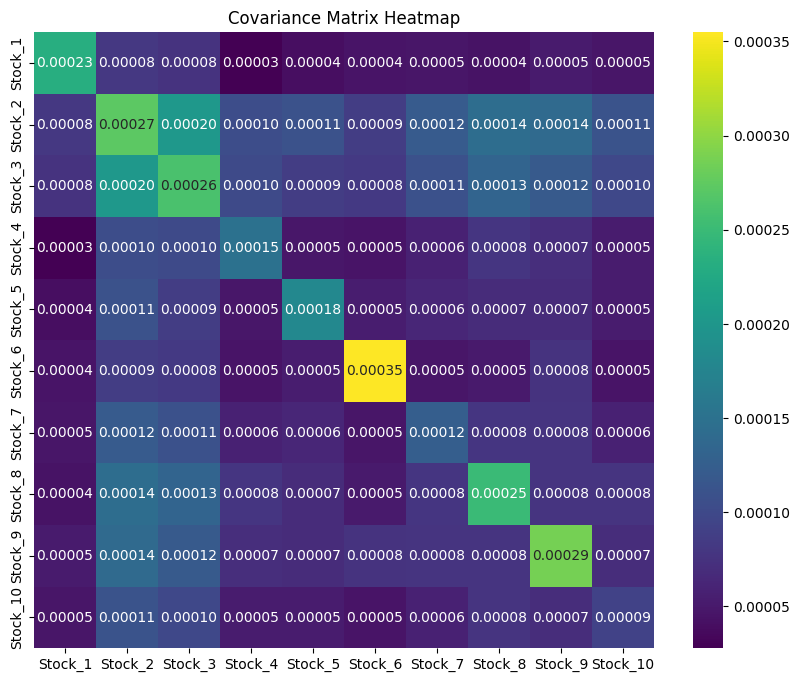

In [30]:
#covariance heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    covariance_matrix,
    annot=True,
    cmap="viridis",
    fmt=".5f"
)
plt.title("Covariance Matrix Heatmap")
plt.savefig("../plots/covariance_heatmap.png")
plt.show()

In [31]:
# highest and lowest correlation pairs

corr_pairs = correlation_matrix.unstack()
# remove self correlation as we do not want stock's correlation with itself, that will give 1.0
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
# Remove duplicate pairs - as correlation matrix is symmetric - duplicate pairs may occur
corr_pairs = corr_pairs.drop_duplicates()
highest_corr = corr_pairs.idxmax()
lowest_corr = corr_pairs.idxmin()
print("Highest Correlation Pair:", highest_corr)
print("Correlation Value:", corr_pairs.max())
print()
print("Lowest Correlation Pair:", lowest_corr)
print("Correlation Value:", corr_pairs.min())

Highest Correlation Pair: ('Stock_2', 'Stock_3')
Correlation Value: 0.7585826477430195

Lowest Correlation Pair: ('Stock_1', 'Stock_4')
Correlation Value: 0.1484269687325068


# Observation from Correlation and Covariance Analysis 

- The correlation heatmap shows that many stocks move together because all of them are influenced by the same common market factor used in the data generation process.
- Some stock pairs show stronger correlation than others because certain stocks react more strongly to market movements due to higher beta values.
- The covariance matrix shows how the returns of different stocks vary together. Stocks with larger fluctuations generally produce larger covariance values.
- Overall, the heatmaps indicate that the stocks are not independent and share an underlying relationship structure. This hidden structure is what PCA later tries to identify and summarize using a smaller number of principal components.
- The highest correlation pair corresponds to the two stocks that move most similarly, while the lowest correlation pair corresponds to stocks with relatively weak or less similar movements.

# (d)

Standardize the returns to zero mean and unit variance. Explain why standardization matters when stocks have different volatilities. What happens to PCA results if you skip this step?


In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
# Standardize returns

# scaler = StandardScaler()
# # creates scaling object
# standardized_returns = scaler.fit_transform(log_returns)
# # standardize to make each stock's mean =0 and standard deviation = 1.
# standardized_returns = pd.DataFrame(
#     standardized_returns,
#     columns=log_returns.columns
# )
# display(standardized_returns.head())


standardized_returns = standardize_returns(log_returns)
display(standardized_returns.head())

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
1,-1.317191,0.349922,0.460416,-0.635845,0.740845,-1.350615,0.204899,-0.690553,-0.344059,0.319819
2,-0.937532,-0.706486,0.088337,-0.923275,0.418441,-1.231057,-0.071812,0.814423,-2.378358,-0.984583
3,0.503418,-0.353017,-0.025836,-0.766717,-0.085982,-0.250610,0.607911,0.057647,0.101038,-0.501960
4,-0.591525,-0.728084,-0.268248,-0.790219,-0.064192,1.625648,0.171954,-0.612168,0.639850,-0.754962
5,-1.194929,1.211895,0.440942,0.697418,0.944010,2.161051,1.550606,1.069718,1.687908,0.196694


In [34]:

standardized_returns.to_csv(
    "../data/standardized_returns.csv",
    index=False
)

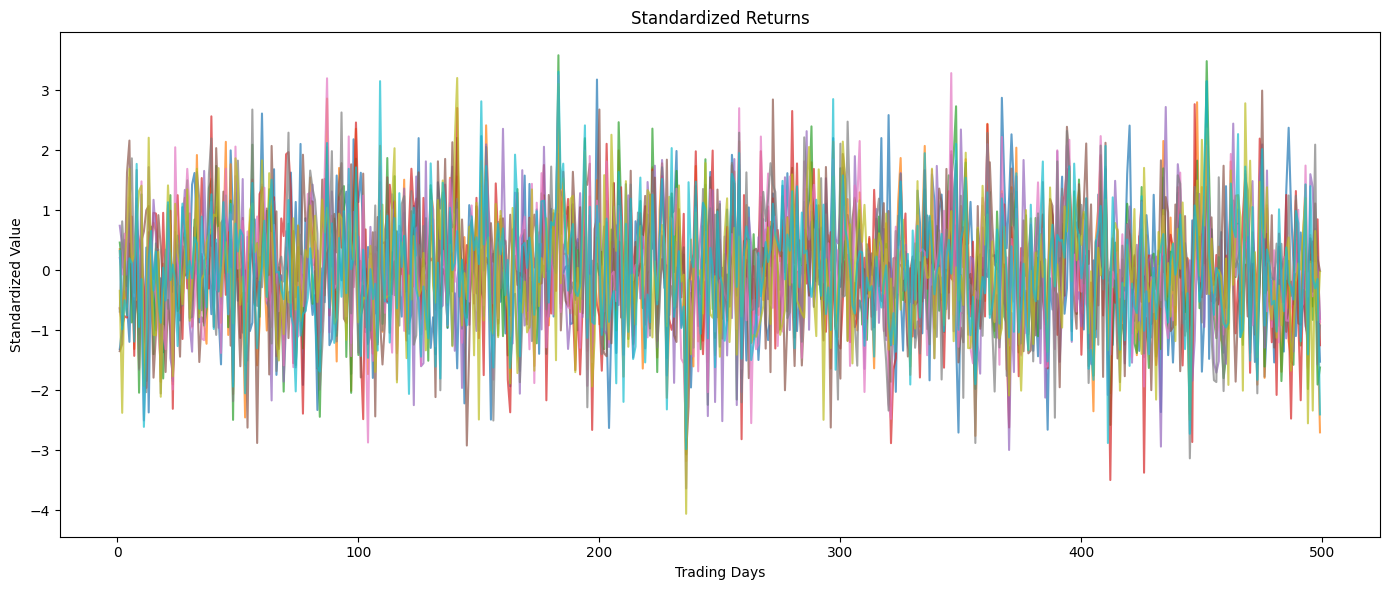

In [35]:
# Plot standardized returns - visual proof of standardization worked.

plt.figure(figsize=(14,6))
for col in standardized_returns.columns:
    plt.plot(standardized_returns[col], alpha=0.7)
plt.title("Standardized Returns")
plt.xlabel("Trading Days")
plt.ylabel("Standardized Value")
plt.tight_layout()
plt.savefig("../plots/standardized_returns.png")
plt.show()

In [74]:
pd.DataFrame({
    "Stock": range(10),
    "Drift": mu
})

,Stock,Drift
0,0,0.000250
1,1,0.000480
2,2,0.000393
3,3,0.000339
4,4,0.000162
5,5,0.000162
6,6,0.000123
7,7,0.000446
8,8,0.000340
9,9,0.000383


# Explain why standardization matters when stocks have different volatilities. What happens to PCA results if you skip this step?

Currently our stocks have different volatilities, some stocks fluctuate alot, some very little. Now beacuse PCA works by finding directions with maximum variance, so naturally, high volatlity stocks produce larger variance and PCA will start focusing on them mostly even if othr stocks contain important structures. So to avoid PCA becoming biased towards magnitude of movement instead of focusing on actual relationship structure, standardization is important.

Standardization transform each stock's returns so that
- mean becomes 0
- variance becomes 1
So all stocks now contribute equally to PCA regardless of their original volatility levels.

The standardized return visualization further confirms this effect. Before standardization, some stocks fluctuate much more strongly than others. After scaling, the return series appear on a comparable scale, preventing any single stock from dominating the analysis purely because of higher volatility.

As a result, PCA is able to focus on the true correlation structure and common market behavior rather than differences in variance magnitude.

If standardization is skipped, the first few principal components may become biased toward only the most volatile stocks, leading to less meaningful factor interpretation.


# (e)

 Write down all your observations.

# PART 1 Observations

- The generated stock prices showed realistic market-like movement over time.

- Since all stocks were affected by the same common market factor, many of them moved together, creating correlation between assets.

- Stocks with higher beta values reacted more strongly to market changes and therefore showed larger upward or downward movements.

- Converting prices into log returns removed most of the long-term trend and made the data more stable for analysis.

- The correlation and covariance heatmaps showed that the stocks were not independent and shared common movement patterns.

- Some stock pairs had strong correlation because they reacted similarly to the market factor, while others showed weaker relationships due to random stock-specific noise.

- Standardization placed all return series on a similar scale by making their mean close to 0 and variance close to 1.

- After standardization, no single stock dominated the analysis simply because of higher volatility.

- Overall, the dataset showed a clear hidden market structure, making it suitable for applying PCA in the next part of the project.

# PART 2 - Understanding PCA and Eigendecomposition

# (a)
Perform PCA on the standardized returns from Part 1(d). Extract eigenvalues and
eigenvectors. Plot a scree chart showing the proportion of variance explained by each component.
How many components are needed to explain ≥ 80% of total variance?

In [36]:
from sklearn.decomposition import PCA

In [37]:
# # PCA on standardized returns
# pca = PCA()
# pca.fit(standardized_returns)
pca, eigenvalues, eigenvectors, explained_variance_ratio = perform_pca(standardized_returns)

In [72]:
# # Eigenvalues
# eigenvalues = pca.explained_variance_
print(eigenvalues)
# # Eigenvectors(principal component directions)
# eigenvectors = pca.components_
display(eigenvectors)

[4.65730194 0.93341651 0.86777926 0.73131497 0.70355745 0.58575006
 0.52542142 0.44773726 0.35183571 0.21596574]


array([[ 1.93084305e-01,  4.12580801e-01,  3.89177473e-01,
         3.00268217e-01,  2.75968201e-01,  1.80659610e-01,
         3.55113975e-01,  3.10125181e-01,  2.83571251e-01,
         3.73340149e-01],
       [ 5.82255498e-01, -7.04097366e-02, -8.52434208e-02,
        -2.75822273e-01,  6.19209286e-02,  6.75823148e-01,
        -6.79440717e-02, -3.04931366e-01,  1.09324627e-01,
        -5.05381010e-02],
       [ 7.20730249e-01,  4.05768819e-02,  4.29631772e-02,
        -1.81717821e-01, -6.78824042e-02, -6.29035963e-01,
         6.97930602e-02,  1.82511372e-02, -1.74714235e-01,
         8.95026329e-02],
       [-1.54329720e-01,  3.62473151e-02, -1.23722814e-01,
        -3.56677660e-01,  8.72378548e-01, -1.62526272e-01,
         1.18472880e-01, -1.60255838e-01, -4.10867566e-02,
        -5.89676465e-02],
       [-4.96673372e-02,  2.10001723e-02, -3.04732753e-02,
        -3.48968349e-02, -1.24296921e-01, -2.85286259e-01,
         3.25815943e-02, -4.11741108e-01,  8.51823424e-01,
        -4.

In [39]:
pd.DataFrame(eigenvalues).to_csv(
    "../data/eigenvalues.csv",
    index=False
)
pd.DataFrame(eigenvectors).to_csv(
    "../data/eigenvectors.csv",
    index=False
)

In [40]:
# explained_variance_ratio = pca.explained_variance_ratio_
print(explained_variance_ratio)
#converts raw variance into %contribution

[0.46479687 0.09315459 0.08660402 0.07298494 0.07021475 0.05845762
 0.05243685 0.044684   0.03511306 0.02155329]


In [41]:
pd.DataFrame(
    explained_variance_ratio
).to_csv(
    "../data/explained_variance_ratio.csv",
    index=False
)

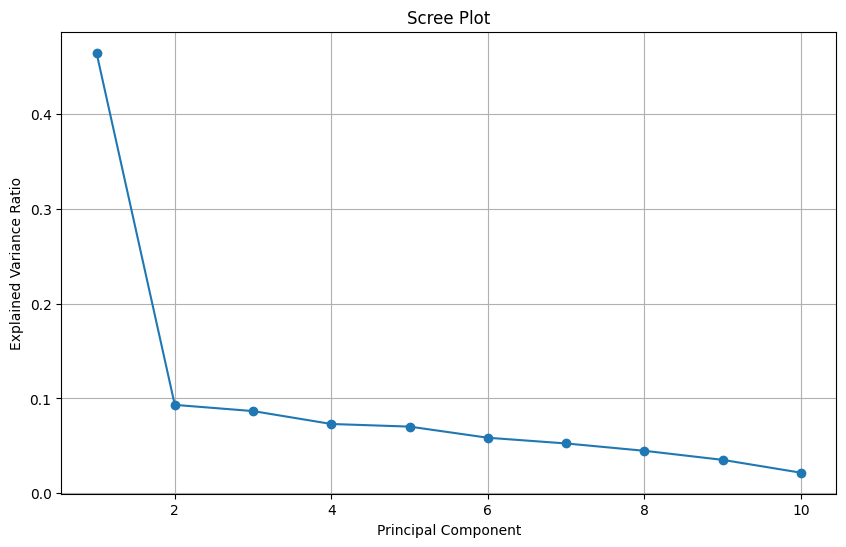

In [42]:
# Scree plot

plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(explained_variance_ratio)+1),
    explained_variance_ratio,
    marker='o'
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.savefig("../plots/scree_plot.png")
plt.show()

In [43]:
# cumulative variance - to find how many components explain 80% variance.
cumulative_variance = np.cumsum(
    explained_variance_ratio
)
print(cumulative_variance)

[0.46479687 0.55795146 0.64455548 0.71754042 0.78775517 0.8462128
 0.89864964 0.94333364 0.97844671 1.        ]


In [44]:
pd.DataFrame(
    cumulative_variance
).to_csv(
    "../data/cumulative_variance.csv",
    index=False
)

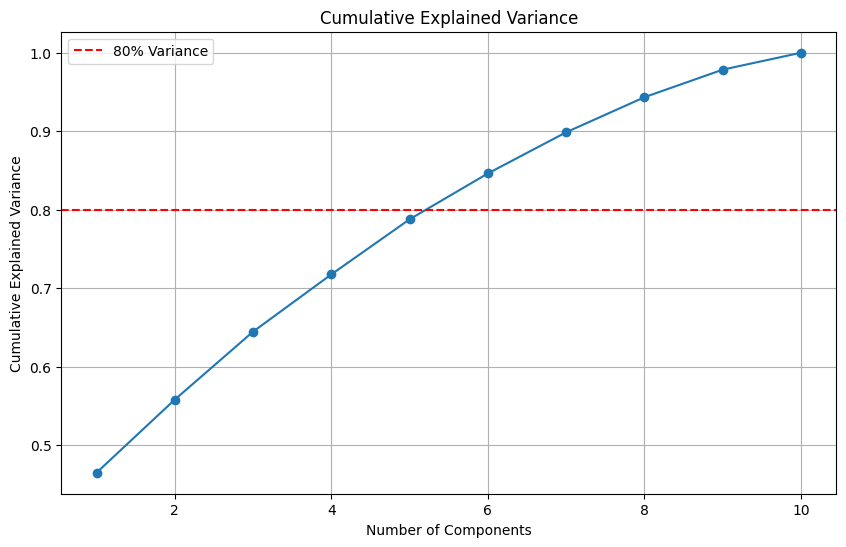

In [45]:
# cumulative variance plot - Can the stock market be summarized using only a few hidden factors?

plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)
plt.axhline(
    y=0.80,
    color='red',
    linestyle='--',
    label='80% Variance'
)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.savefig("../plots/cumulative_variance.png")
plt.show()

In [46]:
# components required for 80% variance

components_80 = (
    np.argmax(cumulative_variance >= 0.80)
    + 1
)
print(
    "Components required for 80% variance:",
    components_80
)

Components required for 80% variance: 6


## Understanding Cumulative Explained Variance

The explained variance ratio tells us how much information each principal component captures individually.

For example:

| Principal Component | Explained Variance |
|---------------------|-------------------|
| PC1 | 50% |
| PC2 | 20% |
| PC3 | 10% |

This means:
- PC1 alone explains 50% of the total variability in the market
- PC1 + PC2 together explain 70%
- PC1 + PC2 + PC3 together explain 80%

The cumulative explained variance is obtained by continuously adding the explained variance of each component.

Its purpose is to determine how many principal components are sufficient to preserve most of the information present in the original dataset.

Originally, the system contains 10 stock dimensions. However, if only 3 principal components explain more than 80% of the variance, then the market can effectively be represented using only 3 hidden factors instead of all 10 original variables.

The cumulative variance plot visually shows how quickly information accumulates as more principal components are added.

If the curve rises rapidly and becomes flatter after a few components, it indicates that:
- the first few principal components capture most of the important market structure
- later components contribute relatively little additional information and may mostly represent noise

The horizontal 80% line is used as a common threshold for selecting the minimum number of components required to retain most of the dataset’s information while still achieving dimensionality reduction.

This helps answer an important PCA question:

"How many hidden factors are enough to represent most market behavior?"
or as stated explicitly in question -
"How many components are needed to explain ≥ 80% of total variance?"

# (b)
Now perform PCA on the covariance matrix (i.e., on unstandardized returns). Compare the
eigenvalues and explained variance ratios with those from (a). Are they the same? Explain why or
why not, with reference to the differing stock volatilities.

In [47]:
# PCA on unstandardized log returns

pca_raw = PCA()
pca_raw.fit(log_returns)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [48]:
# Eigenvalues 

raw_eigenvalues = pca_raw.explained_variance_
display(raw_eigenvalues)

array([9.86215054e-04, 3.05706674e-04, 2.04746104e-04, 1.96200708e-04,
       1.37381962e-04, 1.23064457e-04, 9.20351336e-05, 6.31780193e-05,
       5.77330162e-05, 3.79353654e-05])

In [49]:
pd.DataFrame(
    raw_eigenvalues
).to_csv(
    "../data/raw_eigenvalues.csv",
    index=False
)

In [50]:
# Compare eigenvalues

eigenvalue_comparison = pd.DataFrame({
    "Standardized PCA Eigenvalues":
        eigenvalues,

    "Raw PCA Eigenvalues":
        raw_eigenvalues
})
display(eigenvalue_comparison)

,Standardized PCA Eigenvalues,Raw PCA Eigenvalues
0,4.657302,0.000986
1,0.933417,0.000306
2,0.867779,0.000205
3,0.731315,0.000196
4,0.703557,0.000137
5,0.585750,0.000123
6,0.525421,0.000092
7,0.447737,0.000063
8,0.351836,0.000058
9,0.215966,0.000038


In [51]:
eigenvalue_comparison.to_csv(
    "../data/eigenvalue_comparison.csv",
    index=False
)

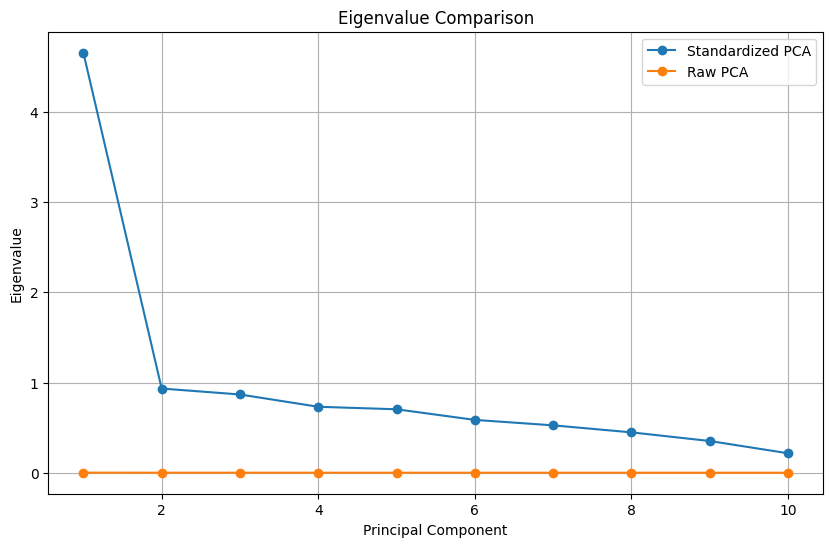

In [52]:
# eigenvalue comparison - visualized

plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(eigenvalues)+1),
    eigenvalues,
    marker='o',
    label='Standardized PCA'
)
plt.plot(
    range(1, len(raw_eigenvalues)+1),
    raw_eigenvalues,
    marker='o',
    label='Raw PCA'
)
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title(
    "Eigenvalue Comparison"
)
plt.legend()
plt.grid(True)
plt.savefig(
    "../plots/eigenvalue_comparison.png"
)
plt.show()

# Are eigenvalues the same?
- The eigenvalues from raw PCA are different from those from standardized PCA because the stocks have different volatility levels.

- In raw PCA, highly volatile stocks contribute larger variance values and therefore influence the principal components more strongly.

- As a result, the first few eigenvalues become larger and PCA focuses more on volatility magnitude.

- In standardized PCA, all stocks are scaled to unit variance, so the eigenvalues reflect shared market structure more fairly.

In [53]:
# Explained variance ratio 

raw_explained_variance = (
    pca_raw.explained_variance_ratio_
)
display(raw_explained_variance)

array([0.44742611, 0.13869302, 0.09288923, 0.08901235, 0.06232746,
       0.05583189, 0.04175451, 0.02866261, 0.02619232, 0.01721052])

In [54]:
pd.DataFrame(
    raw_explained_variance
).to_csv(
    "../data/raw_explained_variance_ratio.csv",
    index=False
)

In [55]:
# Compare explained variance ratios

comparison_df = pd.DataFrame({
    "Standardized PCA":
        explained_variance_ratio,

    "Raw PCA":
        raw_explained_variance
})
display(comparison_df)

,Standardized PCA,Raw PCA
0,0.464797,0.447426
1,0.093155,0.138693
2,0.086604,0.092889
3,0.072985,0.089012
4,0.070215,0.062327
5,0.058458,0.055832
6,0.052437,0.041755
7,0.044684,0.028663
8,0.035113,0.026192
9,0.021553,0.017211


In [56]:
comparison_df.to_csv(
    "../data/pca_comparison.csv",
    index=False
)

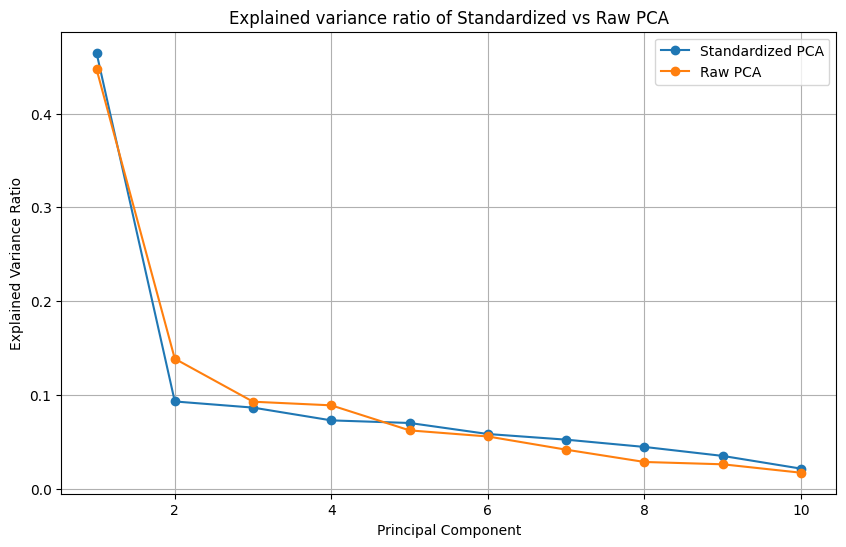

In [57]:
# Compare explained variance ratios - visualized

plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(explained_variance_ratio)+1),
    explained_variance_ratio,
    marker='o',
    label='Standardized PCA'
)
plt.plot(
    range(1, len(raw_explained_variance)+1),
    raw_explained_variance,
    marker='o',
    label='Raw PCA'
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title(
    "Explained variance ratio of Standardized vs Raw PCA"
)
plt.legend()
plt.grid(True)
plt.savefig(
    "../plots/pca_comparison.png"
)
plt.show()

# Are explained variance ratio the same?
- The explained variance ratios are also different for raw and standardized PCA.

- In raw PCA, stocks with higher volatility dominate the variance calculation, causing the first few principal components to explain a larger share of total variance.

- In standardized PCA, all stocks contribute more equally, leading to a more balanced distribution of explained variance across components.

- Therefore, standardized PCA captures common market relationships more effectively instead of being dominated by high-volatility assets.

# (c)
Inspect the loadings (eigenvector components) of PC1. Are all loadings the same sign? What does this represent financially? Now inspect PC2 — do the loadings split stocks into groups? Hypothesize what "factor" PC2 could represent.

In [58]:
# PC1 loadings

pc1_loadings = pd.Series(
    eigenvectors[0],
    index=standardized_returns.columns
)
display(pc1_loadings)


Stock_1     0.193084
Stock_2     0.412581
Stock_3     0.389177
Stock_4     0.300268
Stock_5     0.275968
Stock_6     0.180660
Stock_7     0.355114
Stock_8     0.310125
Stock_9     0.283571
Stock_10    0.373340
dtype: float64

In [59]:
pc1_loadings.to_csv(
    "../data/pc1_loadings.csv"
)

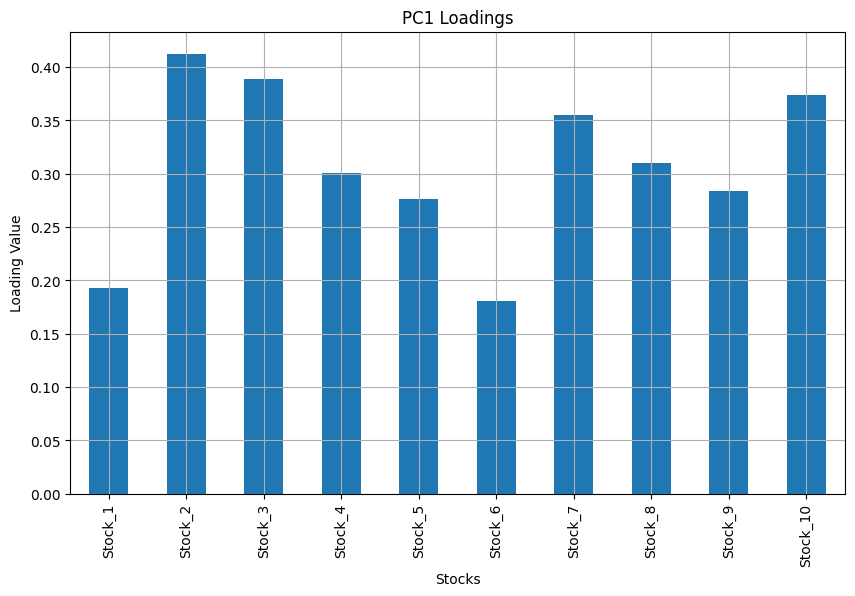

In [60]:
# plot PC1 loadings

plt.figure(figsize=(10,6))
pc1_loadings.plot(kind='bar')
plt.xlabel("Stocks")
plt.ylabel("Loading Value")
plt.title("PC1 Loadings")
plt.grid(True)
plt.savefig(
    "../plots/pc1_loadings.png"
)
plt.show()

In [61]:
# PC2 loadings

pc2_loadings = pd.Series(
    eigenvectors[1],
    index=standardized_returns.columns
)
display(pc2_loadings)

Stock_1     0.582255
Stock_2    -0.070410
Stock_3    -0.085243
Stock_4    -0.275822
Stock_5     0.061921
Stock_6     0.675823
Stock_7    -0.067944
Stock_8    -0.304931
Stock_9     0.109325
Stock_10   -0.050538
dtype: float64

In [62]:
pc2_loadings.to_csv(
    "../data/pc2_loadings.csv"
)

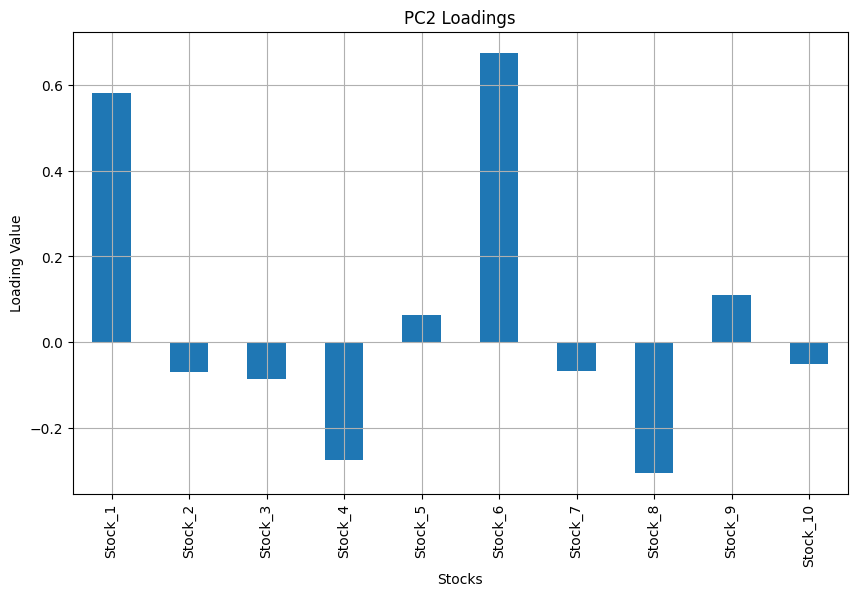

In [63]:
# plot PC2 loadings
plt.figure(figsize=(10,6))
pc2_loadings.plot(kind='bar')
plt.xlabel("Stocks")
plt.ylabel("Loading Value")
plt.title("PC2 Loadings")
plt.grid(True)
plt.savefig(
    "../plots/pc2_loadings.png"
)
plt.show()

# Interpretation of PC1 and PC2 Loadings

The loadings represent the contribution of each stock to a principal component.

For PC1, most loadings have the same sign, indicating that the stocks tend to move together in a common direction. This suggests that PC1 captures the overall market movement or common market factor affecting all assets.

In PC2, the loadings may split into positive and negative groups. This indicates that PC2 captures differences between groups of stocks rather than overall market movement.

Such separation could represent:
- high-beta vs low-beta stocks
- more volatile vs less volatile assets
- different reaction strengths to the market factor

Therefore, hypothesizing, PC2 can be interpreted as a secondary market factor that distinguishes relative behavior among stocks.

# (d)
Compute the scores (projections of each day's returns onto the principal components). Plot the PC1 score time series. Does it resemble any known market quantity?

In [73]:
# PCA scores

# scores = pca.transform(
#     standardized_returns
# )
# display(scores)

scores = compute_scores(standardized_returns.values, eigenvectors)
scores = pd.DataFrame(scores, columns=[f"PC{i+1}" for i in range(scores.shape[1])])
display(scores)



,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-0.280810,-1.379477,0.089913,1.381818,0.358097,-0.207923,0.969621,-0.705827,0.270855,-0.061107
1,-1.637229,-1.508795,0.550432,1.019335,-1.960108,-0.455851,0.270156,0.483699,0.665684,-0.352771
2,-0.282720,0.334494,0.631101,0.240131,0.181398,-0.484947,0.211734,0.802464,0.101247,-0.238634
3,-0.709508,1.325439,-1.520568,0.196434,0.429755,-0.477944,0.289732,0.608626,0.093053,-0.346269
4,2.735696,0.250953,-2.492848,0.328666,0.352441,-0.574575,0.027408,1.029468,-0.134616,0.415588
...,...,...,...,...,...,...,...,...,...,...
494,1.683185,0.546221,0.014817,1.020693,-0.315517,0.388598,-0.209971,-0.932960,-0.539985,-0.099706
495,-1.058948,-0.130730,-0.214648,1.248563,-2.058488,1.343845,0.001044,-0.333954,-0.480593,-0.021357
496,1.298000,0.379116,-0.465728,-0.600892,-0.598267,-1.168611,-1.224126,0.899338,0.302110,0.510963
497,-1.789274,0.383124,-0.564131,0.347285,-0.130925,1.740139,0.045970,-0.201072,-1.383032,0.256026


In [65]:
scores_df = pd.DataFrame(
    scores,
    columns=[
        f"PC{i+1}"
        for i in range(scores.shape[1])
    ]
)
display(scores_df.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-0.280810,-1.379477,0.089913,1.381818,0.358097,-0.207923,0.969621,-0.705827,0.270855,-0.061107
1,-1.637229,-1.508795,0.550432,1.019335,-1.960108,-0.455851,0.270156,0.483699,0.665684,-0.352771
2,-0.282720,0.334494,0.631101,0.240131,0.181398,-0.484947,0.211734,0.802464,0.101247,-0.238634
3,-0.709508,1.325439,-1.520568,0.196434,0.429755,-0.477944,0.289732,0.608626,0.093053,-0.346269
4,2.735696,0.250953,-2.492848,0.328666,0.352441,-0.574575,0.027408,1.029468,-0.134616,0.415588


In [66]:
scores_df.to_csv(
    "../data/pca_scores.csv",
    index=False
)

In [67]:
# PC1 scores

pc1_scores = scores_df["PC1"]
display(pc1_scores.head())

0   -0.280810
1   -1.637229
2   -0.282720
3   -0.709508
4    2.735696
Name: PC1, dtype: float64

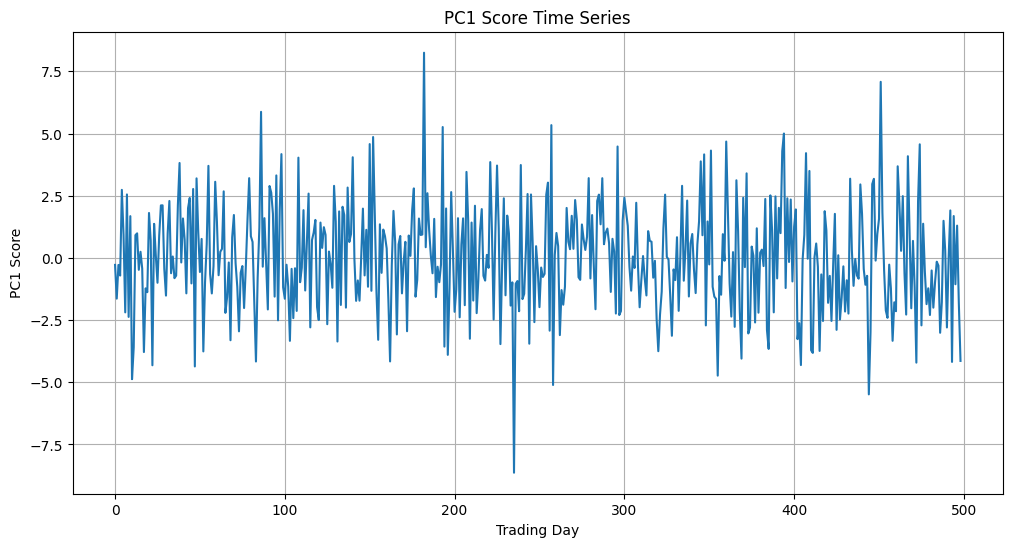

In [68]:
#Plot PC1 score time series

plt.figure(figsize=(12,6))
plt.plot(
    pc1_scores
)
plt.xlabel("Trading Day")
plt.ylabel("PC1 Score")
plt.title(
    "PC1 Score Time Series"
)
plt.grid(True)
plt.savefig(
    "../plots/pc1_scores.png"
)
plt.show()

#  Does PC1 score time series resemble any known market quantity?

The PC1 score series tracks the behavior of the first principal component over time.

Since PC1 captures the maximum variance and represents the common movement shared across most stocks, its score series resembles a broad market index or overall market sentiment indicator.

Large positive PC1 scores indicate strong market-wide upward movement, while large negative scores indicate market-wide downward movement.

Therefore, the PC1 score time series behaves similarly to a synthetic market factor representing the dominant movement pattern across the entire market.

# (e)
A colleague claims: "The loadings vector IS the same thing as the scores vector." Disprove this claim by showing their shapes, units, and interpretations differ

In [69]:


print(
    "Eigenvector shape:",
    eigenvectors.shape
)
print(
    "Scores shape:",
    scores.shape
)

Eigenvector shape: (10, 10)
Scores shape: (499, 10)


In [70]:
# comparison table

comparison = pd.DataFrame({
    "Aspect": [
        "Meaning",
        "Represents",
        "Shape",
        "Interpretation"
    ],
    "Loadings": [
        "Weights of stocks in PCs",
        "Variables/features",
        str(eigenvectors.shape),
        "Contribution of each stock"
    ],
    "Scores": [
        "Projection values",
        "Observations/days",
        str(scores.shape),
        "Strength of PC on each day"
    ]
})
display(comparison)

,Aspect,Loadings,Scores
0,Meaning,Weights of stocks in PCs,Projection values
1,Represents,Variables/features,Observations/days
2,Shape,"(10, 10)","(499, 10)"
3,Interpretation,Contribution of each stock,Strength of PC on each day


In [71]:
comparison.to_csv(
    "../data/loadings_vs_scores.csv",
    index=False
)

# Difference between Loadings and Scores 

The loadings (eigenvectors) represent the contribution of each stock to a principal component. They describe the direction of maximum variance in feature space.

The scores represent the projection of each day’s returns onto the principal components. They describe how strongly each observation follows a particular component.

Their shapes are different:
- Loadings shape = (number of principal components × number of stocks)
- Scores shape = (number of observations × number of principal components)

Their interpretations are also different:
- Loadings explain relationships between stocks and principal components
- Scores explain the behavior of each trading day in the PCA transformed space

Their Units are also different:
- Loadings are dimensionless as they are normalized direction vactors, relative weights.
- scores are in standardized return units that is magnitude of market movement or the strength along PC direction

Therefore, loadings and scores are fundamentally different mathematical objects and serve different purposes in PCA analysis.

Simple analogy 
- Loadings = recipe
- Scores = final dish intensity

that is,
- Loadings = directions
- Scores = positions along directions

# (f)
Report all your observations 


# Part 2 Observations

- PCA reduced the complexity of the dataset by representing the stock movements using only a few important components.

- The first principal component (PC1) explained most of the variance, showing that many stocks were moving together because of a common market factor.

- The scree plot showed that the importance of components decreased after the first few principal components.

- The cumulative variance plot showed that only a small number of components were needed to preserve most of the information in the dataset.

- PCA on raw returns and standardized returns gave different results because highly volatile stocks influenced the raw PCA more strongly.

- Standardization helped all stocks contribute more equally to the PCA process.

- The PC1 loadings mostly had the same sign, indicating that most stocks moved in a similar direction.

- The PC2 loadings split stocks into different groups, suggesting another hidden factor affecting stocks differently.

- The PC1 score series behaved similarly to a market index and represented the overall market movement over time.

- Loadings and scores were different:
  - loadings showed how stocks contributed to components
  - scores showed how each trading day behaved along those components

- Overall, PCA successfully identified hidden market structure and common movement patterns in the synthetic stock data.